In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import matplotlib.dates as mdates

In [4]:
c_aowb = '#e87c89'
c_owb = '#31587f'

In [5]:
L4_chlor = pd.read_csv("/gws/pw/j25/rep/dapa/obs_for_oscar/L4_data/chlorophyll_a_wco_19922022_dataset_sheet1.csv",
                       na_values=-99
                      )

L4_chlor['date'] = pd.to_datetime(L4_chlor[['Year', 'Month', 'Day']])

In [6]:
L4_chlor = L4_chlor[L4_chlor['Year'] == 2018].sort_values('date')

L4_chlor_surface = L4_chlor[L4_chlor[' Depth (metres)'] == 0].sort_values('date')

In [7]:
AOWB = xr.open_dataset('/gws/pw/j25/rep/omerrett/AOWB_RALP3P3_fixes/Analysis/L4_analysis/L4_Chlorophyll_AOWB.nc')
OWB = xr.open_dataset('/gws/pw/j25/rep/omerrett/OWB/Analysis/L4_analysis/L4_Chlorophyll_OWB.nc')

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(L4_chlor_surface['date'], L4_chlor_surface[' chlorophyll a (µg L-1)'], marker='o')

# Formatting the chart
plt.title('Surface Chlorophyll a Concentration - 2018')
plt.xlabel('Date')
plt.ylabel('Chlorophyll a (µg L-1)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [3]:
plt.figure(figsize=(10, 5))

plt.plot(OWB['2x2'].time_counter, OWB['2x2'].values, label = 'OWB', color = c_owb)
plt.plot(AOWB['2x2'].time_counter, AOWB['2x2'].values, label = 'AOWB', color = c_aowb)
plt.plot(L4_chlor_surface['date'], L4_chlor_surface[' chlorophyll a (µg L-1)'], marker='o', color = 'orange')


# Formatting the chart
plt.title('Surface Chlorophyll a Concentration - 2018')
plt.xlabel('Date')
plt.ylabel('Chlorophyll a (µg L-1)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

NameError: name 'OWB' is not defined

<Figure size 1000x500 with 0 Axes>

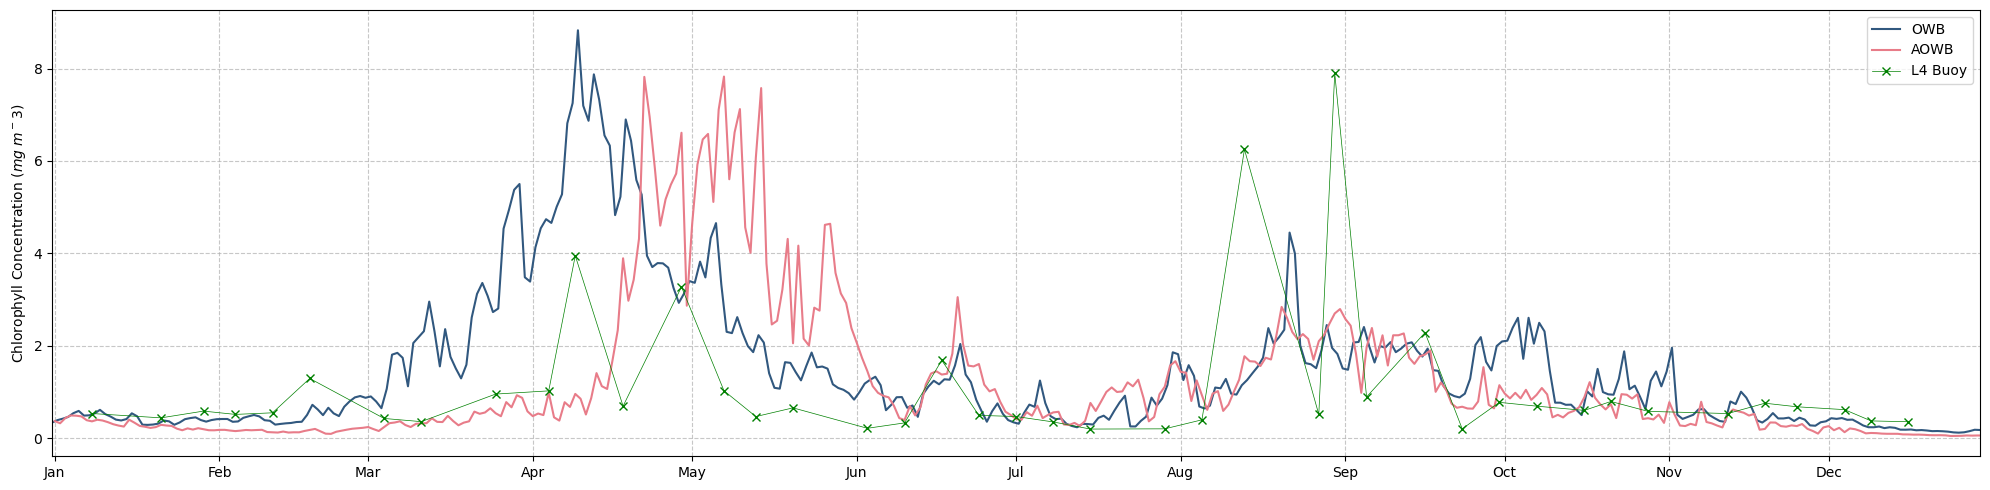

In [8]:
plt.figure(figsize=(20, 5))

plt.plot(OWB['cell_375_725'].time_counter, OWB['cell_375_725'].values, label = 'OWB', color = c_owb)
plt.plot(AOWB['cell_375_725'].time_counter, AOWB['cell_375_725'].values, label = 'AOWB', color = c_aowb)
plt.plot(L4_chlor_surface['date'], L4_chlor_surface[' chlorophyll a (µg L-1)'], marker = 'x',linewidth = 0.5, color = 'green', label = 'L4 Buoy')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday =2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(OWB['cell_375_725'].time_counter.min(),OWB['cell_375_725'].time_counter.max())
# Formatting the chart
plt.xlabel('')
plt.ylabel('Chlorophyll Concentration ($mg$ $m^-3$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.savefig('L4 Chlorophyll Comparison', dpi=600, bbox_inches='tight')

In [9]:
print(L4_chlor.columns.tolist())

['Day', 'Month', 'Year', ' Depth (metres)', ' chlorophyll a (µg L-1)', 'Unnamed: 5', 'Missing data = -99', 'date']


In [10]:
ds = xr.open_dataset('/gws/pw/j25/rep/omerrett/AOWB_RALP3P3_fixes/BGC/enuk_amm15_amm15-SMC_1d_20180102_20171230_25hourm_ptrc_T.nc')


In [11]:
# Target coordinates (L4 Station)
target_lat = 50.25
target_lon = -4.217

# 1. Find the distance between L4 and every grid point
# Assuming 'ds' is your loaded xarray dataset
dist = np.sqrt((ds.nav_lon - target_lon)**2 + (ds.nav_lat - target_lat)**2)

# 2. Get the y, x indices of the minimum distance
jj, ii = np.unravel_index(np.argmin(dist.values), dist.shape)

print(f"Closest Grid Cell: y={jj}, x={ii}")
print(f"Model Coord: {ds.nav_lat[jj, ii].values:.4f}N, {ds.nav_lon[jj, ii].values:.4f}E")

# 3. Define a small zoom area (e.g., 5 cells in each direction)
zoom_y = slice(jj-5, jj+6)
zoom_x = slice(ii-5, ii+6)
subset = ds.isel(y=zoom_y, x=zoom_x)

Closest Grid Cell: y=375, x=725
Model Coord: 50.2552N, -4.2224E


In [12]:
# Check the attributes of your coordinate variables
print(ds.nav_lon.attrs)
print(ds.nav_lat.attrs)

{'standard_name': 'longitude', 'long_name': 'Longitude', 'units': 'degrees_east'}
{'standard_name': 'latitude', 'long_name': 'Latitude', 'units': 'degrees_north'}


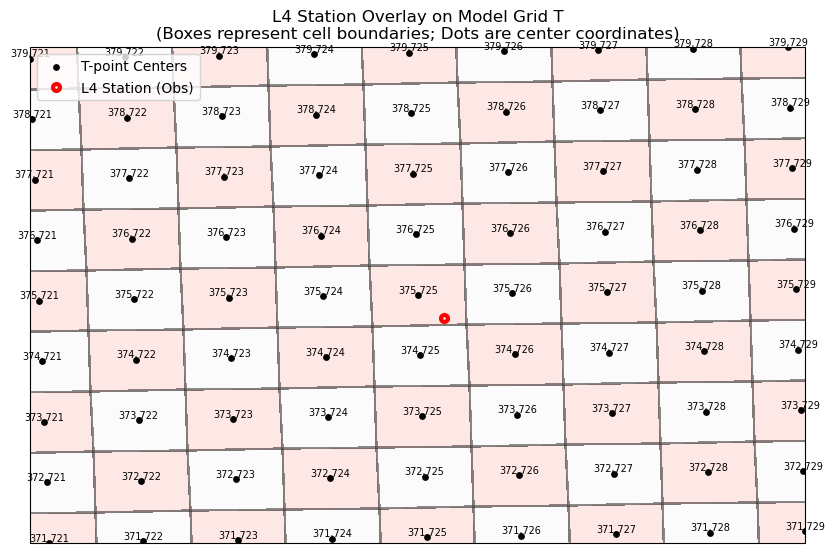

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Define L4 Station (Target)
target_lat, target_lon = 50.2500, -4.2166

# 2. Find Nearest Cell Index
dist = np.sqrt((ds.nav_lon - target_lon)**2 + (ds.nav_lat - target_lat)**2)
jj, ii = np.unravel_index(np.argmin(dist.values), dist.shape)

# 3. Create a small subset around L4
window = 4 
subset = ds.isel(y=slice(jj-window, jj+window+1), x=slice(ii-window, ii+window+1))

# 4. Plotting
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Draw the Grid Cells using 'shading=nearest'
# We use the bathymetry (depth) or a checkerboard to fill the cells
dummy_grid = np.add.outer(np.arange(subset.y.size), np.arange(subset.x.size)) % 2

mesh = ax.pcolormesh(subset.nav_lon, subset.nav_lat, dummy_grid,
                     transform=ccrs.PlateCarree(),
                     shading='nearest',  # Critical: Treats input lons/lats as centers
                     edgecolor='black',   # Draws the grid lines
                     linewidth=1,
                     cmap='Pastel1', 
                     alpha=0.3)

# Plot the T-point Centers (The actual data locations)
ax.scatter(subset.nav_lon, subset.nav_lat, color='black', s=15, 
           transform=ccrs.PlateCarree(), label='T-point Centers')

# Highlight the L4 Station
ax.plot(target_lon, target_lat, 'ro', markersize=5, fillstyle='none', 
        markeredgewidth=3, transform=ccrs.PlateCarree(), label='L4 Station (Obs)')

# Label the indices for clarity
for y in range(subset.y.size):
    for x in range(subset.x.size):
        ax.text(subset.nav_lon[y, x], subset.nav_lat[y, x], 
                f'{jj-window+y},{ii-window+x}', 
                transform=ccrs.PlateCarree(), fontsize=7, ha='center', va='bottom')

# Add context features
ax.add_feature(cfeature.COASTLINE.with_scale('10m'))
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.set_extent([subset.nav_lon.min(), subset.nav_lon.max(), 
               subset.nav_lat.min(), subset.nav_lat.max()])

plt.title(f"L4 Station Overlay on Model Grid T\n(Boxes represent cell boundaries; Dots are center coordinates)")
plt.legend(loc='upper left')
plt.show()

In [14]:
AOWB

<xarray.Dataset> Size: 13kB
Dimensions:       (time_counter: 364)
Coordinates:
    deptht        float32 4B ...
    time_instant  (time_counter) datetime64[ns] 3kB ...
  * time_counter  (time_counter) datetime64[ns] 3kB 2018-01-02 ... 2019-01-01
Data variables:
    cell_375_725  (time_counter) float32 1kB 0.366 0.3193 ... 0.05444 0.05026
    cell_374_725  (time_counter) float32 1kB ...
    cell_375_726  (time_counter) float32 1kB ...
    cell_374_726  (time_counter) float32 1kB ...
    2x2           (time_counter) float32 1kB 0.3752 0.3334 ... 0.05246 0.04971
Attributes:
    description:  Chlorophyll options for L4 station validation
    units:        mg/m^3

In [8]:
L4_temp = xr.open_dataset('/gws/pw/j25/rep/dapa/obs_for_oscar/L4_data/L4_temp.nc')

In [9]:
L4_temp

<xarray.Dataset> Size: 364kB
Dimensions:    (record_num: 15180)
Coordinates:
    time_ref   (record_num) datetime64[ns] 121kB ...
    lat_ref    (record_num) float32 61kB ...
    lon_ref    (record_num) float32 61kB ...
    depth_ref  (record_num) float32 61kB ...
Dimensions without coordinates: record_num
Data variables:
    temp_ref   (record_num) float32 61kB ...
Attributes:
    title:    Temperature at L4

In [10]:
L4_2018 = L4_temp.where(L4_temp.time_ref.dt.year == 2018, drop=True)

In [11]:
L4_surface_temp = L4_2018.where(L4_2018.depth_ref == 2.0, drop=True)
L4_40_temp = L4_2018.where(L4_2018.depth_ref == 40.0, drop=True)

In [12]:
L4_20_temp = L4_2018.where(L4_2018.depth_ref == 20.0, drop=True)

In [13]:
L4_surface_temp = L4_surface_temp.sortby('time_ref')

In [14]:
OWB_temp = xr.open_dataset('/gws/pw/j25/rep/omerrett/OWB/Analysis/L4_analysis/L4_temperature_OWB.nc')
AOWB_temp = xr.open_dataset('/gws/pw/j25/rep/omerrett/AOWB_RALP3P3_fixes/Analysis/L4_analysis/L4_temperature_AOWB.nc')

In [15]:
grd = xr.open_dataset("/home/users/omerrett/mesh_mask.nc").isel(t=0).rename({'z':'depthw'})

reg_depths = {}


xsl = slice(725,727)
ysl = slice(374,375)
e3t = grd.e3t_0.isel(y=ysl,x=xsl).mean(['x','y']) 
depth = -1*grd.gdept_0.isel(x=xsl,y=ysl).mean(['x','y']).values
reg_depths = depth

OWB_temp = OWB_temp.assign_coords(
            deptht=reg_depths
        )

AOWB_temp = AOWB_temp.assign_coords(
            deptht=reg_depths
        )

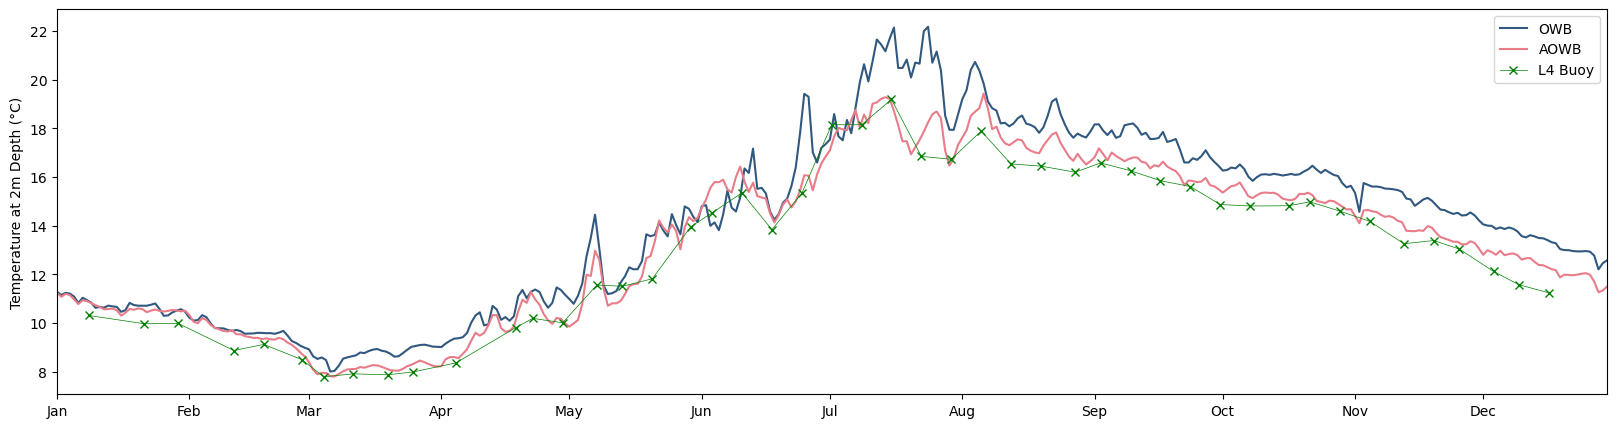

In [16]:
plt.figure(figsize=(20, 5))

plt.plot(OWB_temp['2x2'].isel(deptht = 0).time_counter.values, OWB_temp['2x2'].isel(deptht = 0).values, label = 'OWB',color = c_owb)
plt.plot(AOWB_temp['2x2'].isel(deptht = 0).time_counter.values, AOWB_temp['2x2'].isel(deptht = 0).values, label = 'AOWB',color = c_aowb)


plt.plot(L4_surface_temp.time_ref.values, L4_surface_temp.temp_ref.values, marker = 'x',linewidth = 0.5, label = 'L4 Buoy', color = 'green')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday =2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(OWB_temp['cell_375_725'].time_counter.min(),OWB_temp['cell_375_725'].time_counter.max())

plt.ylabel('Temperature at 2m Depth (°C)')

plt.legend()

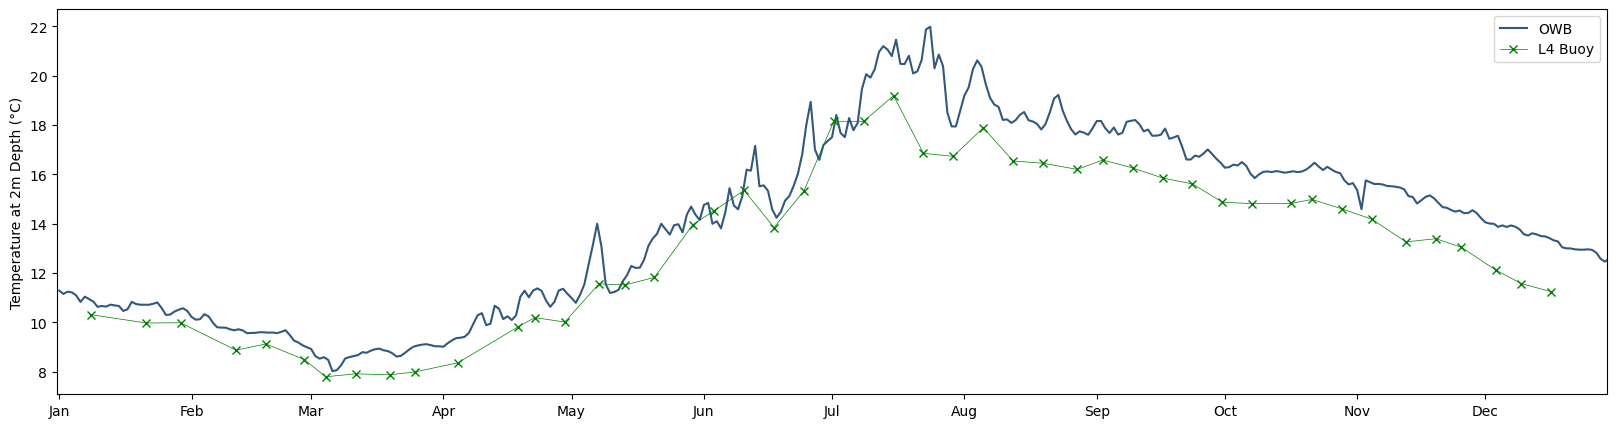

In [17]:
plt.figure(figsize=(20, 5))

plt.plot(OWB_temp['2x2'].isel(deptht = 0).time_counter.values, OWB_temp['2x2'].isel(deptht = 1).values, label = 'OWB',color = c_owb)

plt.plot(L4_surface_temp.time_ref.values, L4_surface_temp.temp_ref.values, marker = 'x',linewidth = 0.5, label = 'L4 Buoy', color = 'green')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday =2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(OWB['cell_375_725'].time_counter.min(),OWB['cell_375_725'].time_counter.max())

plt.ylabel('Temperature at 2m Depth (°C)')

plt.legend()

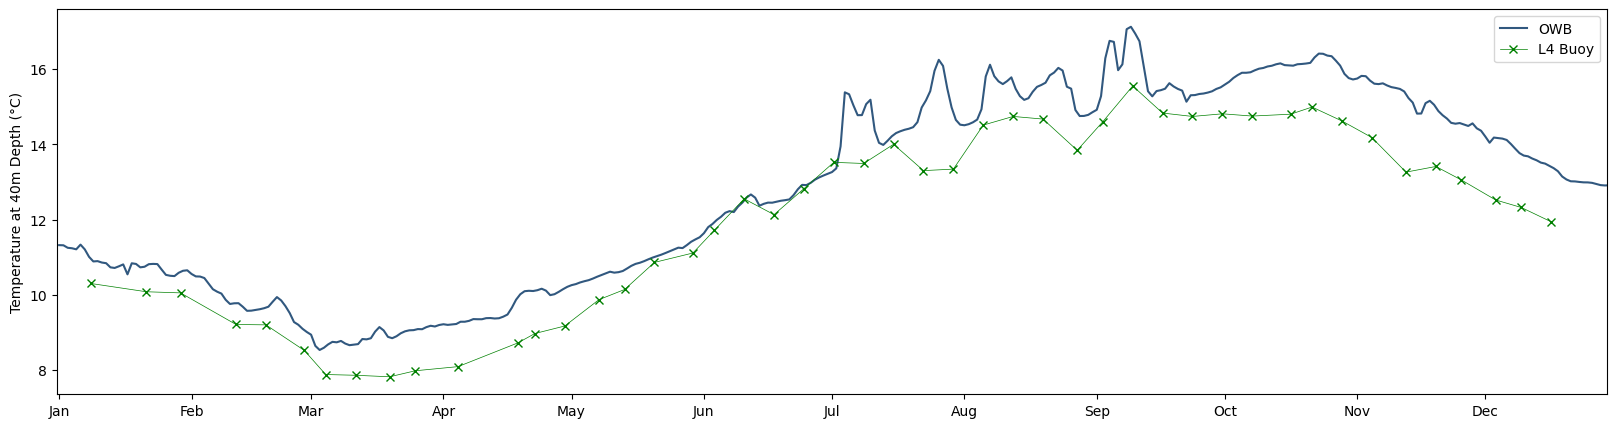

In [18]:
plt.figure(figsize=(20, 5))

plt.plot(OWB_temp['2x2'].isel(deptht = 0).time_counter.values, OWB_temp['2x2'].isel(deptht = 39).values, label = 'OWB',color = c_owb)

plt.plot(L4_40_temp.time_ref.values, L4_40_temp.temp_ref.values, marker = 'x',linewidth = 0.5, label = 'L4 Buoy', color = 'green')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday =2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(OWB['cell_375_725'].time_counter.min(),OWB['cell_375_725'].time_counter.max())

plt.ylabel('Temperature at 40m Depth (°C)')

plt.legend()

In [25]:
OWB_temp

<xarray.Dataset> Size: 376kB
Dimensions:       (time_counter: 363, deptht: 51)
Coordinates:
    time_instant  (time_counter) datetime64[ns] 3kB ...
  * time_counter  (time_counter) datetime64[ns] 3kB 2018-01-02 ... 2018-12-31
  * deptht        (deptht) float32 204B -0.5025 -1.493 -2.464 ... -53.63 -54.66
Data variables:
    cell_375_725  (time_counter, deptht) float32 74kB ...
    cell_374_725  (time_counter, deptht) float32 74kB ...
    cell_375_726  (time_counter, deptht) float32 74kB ...
    cell_374_726  (time_counter, deptht) float32 74kB ...
    2x2           (time_counter, deptht) float32 74kB ...
Attributes:
    description:  Potential Temperature
    units:        celsius

In [26]:
print('DEPTH (m)', OWB_temp.deptht.values)

print('DEPTH (m)', AOWB_temp.deptht.values)

DEPTH (m) [ -0.5024732  -1.4926841  -2.463943   -3.4170988  -4.353032   -5.2726707
  -6.177005   -7.067106   -7.9441376  -8.809372   -9.664201  -10.510144
 -11.348861  -12.18215   -13.011958  -13.840375  -14.669634  -15.502101
 -16.340271  -17.18675   -18.044243  -18.915522  -19.80342   -20.710785
 -21.64046   -22.595238  -23.577824  -24.590788  -25.636518  -26.717165
 -27.834576  -28.990234  -30.185196  -31.420004  -32.69462   -34.008316
 -35.359634  -36.746223  -38.164795  -39.61098   -41.07925   -42.56276
 -44.053257  -45.540928  -47.014282  -48.460007  -49.862793  -51.205227
 -52.46759   -53.62772   -54.660816 ]
DEPTH (m) [ -0.5024732  -1.4926841  -2.463943   -3.4170988  -4.353032   -5.2726707
  -6.177005   -7.067106   -7.9441376  -8.809372   -9.664201  -10.510144
 -11.348861  -12.18215   -13.011958  -13.840375  -14.669634  -15.502101
 -16.340271  -17.18675   -18.044243  -18.915522  -19.80342   -20.710785
 -21.64046   -22.595238  -23.577824  -24.590788  -25.636518  -26.717165
 -27.

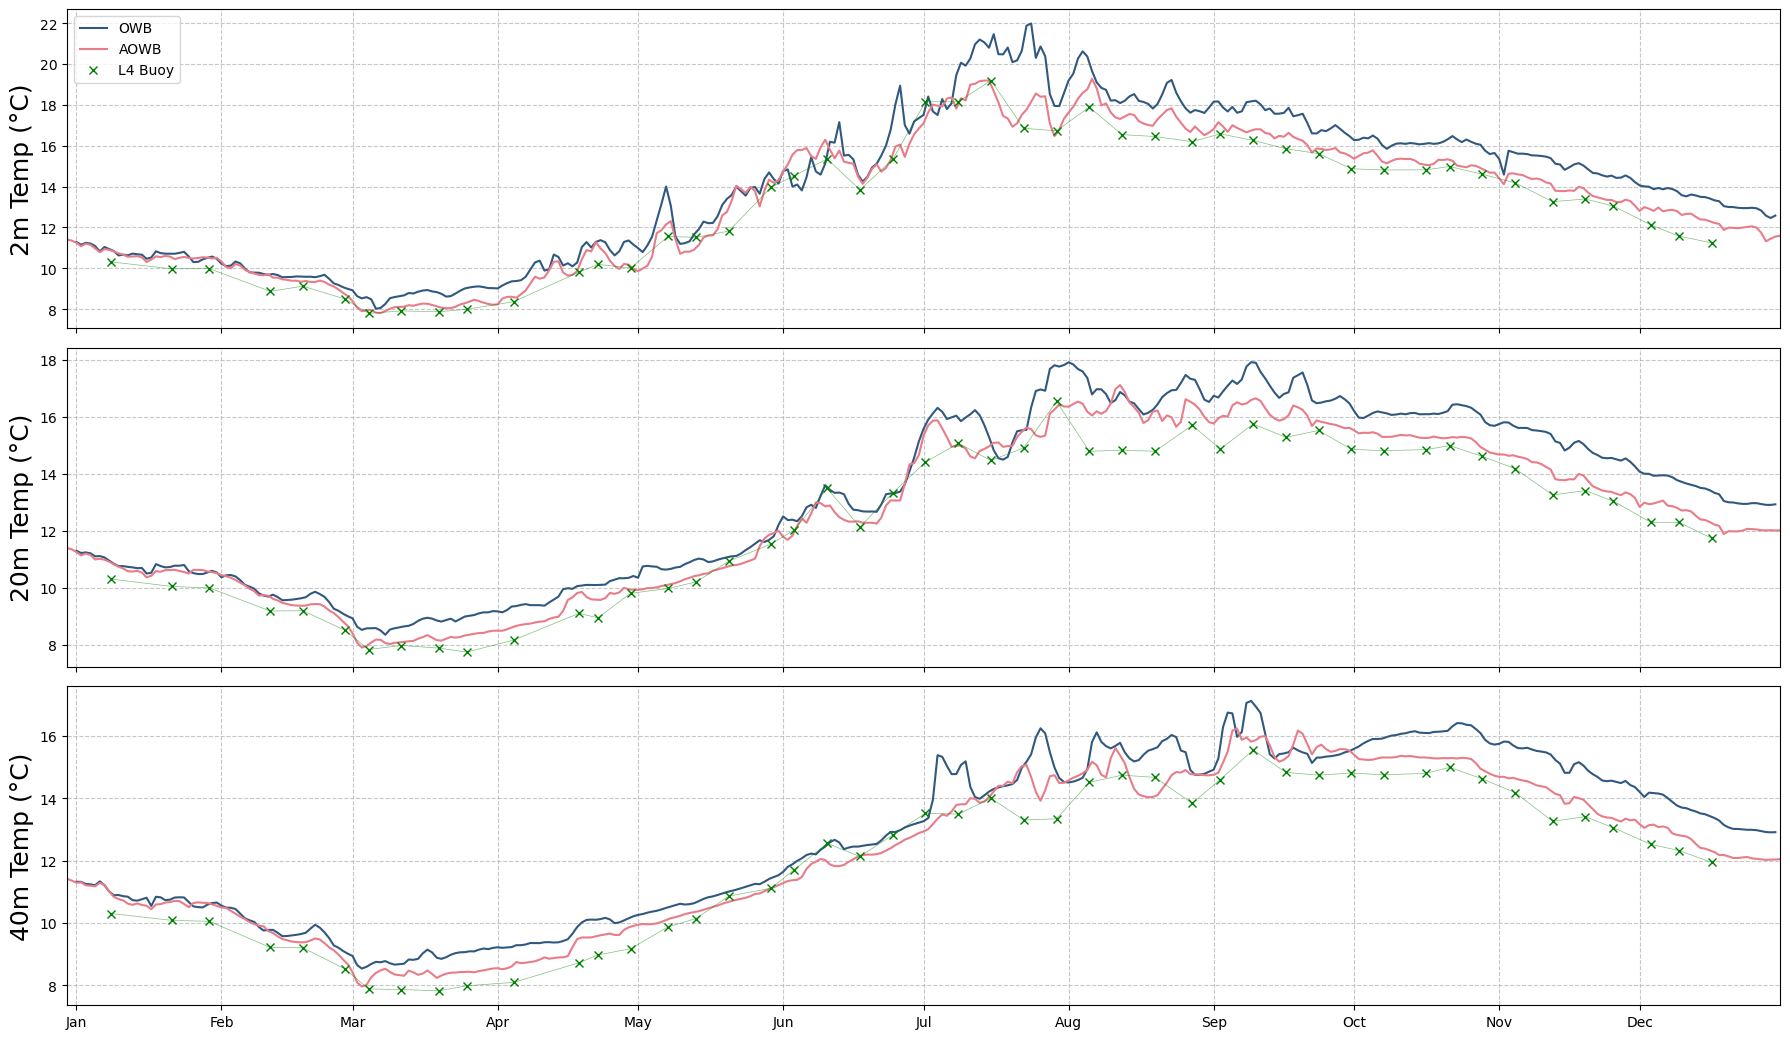

In [41]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fontsize = 18


fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 10.5), sharex=True)

ax1.plot(OWB_temp['2x2'].isel(deptht=1).time_counter, OWB_temp['2x2'].isel(deptht=1).values, 
         label='OWB', color=c_owb)
ax1.plot(AOWB_temp['2x2'].isel(deptht=1).time_counter, AOWB_temp['2x2'].isel(deptht=1).values, 
         label='AOWB', color=c_aowb)
ax1.plot(L4_surface_temp.time_ref, L4_surface_temp.temp_ref, 
         linewidth=0.5, alpha=0.5, color='green')
ax1.plot(L4_surface_temp.time_ref, L4_surface_temp.temp_ref, 
         'x', label='L4 Buoy', color='green')

ax1.set_ylabel('2m Temp (°C)', fontsize = fontsize)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper left')

ax2.plot(OWB_temp['2x2'].sel(deptht= -19.80, method='nearest').time_counter, OWB_temp['2x2'].sel(deptht= -19.80, method='nearest').values, 
         label='OWB', color=c_owb)
ax2.plot(AOWB_temp['2x2'].sel(deptht= -19.80, method='nearest').time_counter, AOWB_temp['2x2'].sel(deptht= -19.80, method='nearest').values, 
         label='AOWB', color=c_aowb)
ax2.plot(L4_20_temp.time_ref, L4_20_temp.temp_ref, 
         linewidth=0.5, alpha=0.5, color='green')
ax2.plot(L4_20_temp.time_ref, L4_20_temp.temp_ref, 
         'x', label='L4 Buoy', color='green')

ax2.set_ylabel('20m Temp (°C)', fontsize = fontsize)
ax2.grid(True, linestyle='--', alpha=0.7)


ax3.plot(OWB_temp['2x2'].sel(deptht= -39.61, method='nearest').time_counter, OWB_temp['2x2'].sel(deptht= -39.61, method='nearest').values, 
         label='OWB', color=c_owb)
ax3.plot(AOWB_temp['2x2'].sel(deptht= -39.61, method='nearest').time_counter, AOWB_temp['2x2'].sel(deptht= -39.61, method='nearest').values, 
         label='AOWB', color=c_aowb)
ax3.plot(L4_40_temp.time_ref, L4_40_temp.temp_ref, 
         linewidth=0.5, alpha=0.5, color='green')
ax3.plot(L4_40_temp.time_ref, L4_40_temp.temp_ref, 
         'x', label='L4 Buoy', color='green')

ax3.set_ylabel('40m Temp (°C)', fontsize = fontsize)
ax3.grid(True, linestyle='--', alpha=0.7)


ax3.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=2))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

time_min = AOWB_temp['2x2'].time_counter.min().values
time_max = AOWB_temp['2x2'].time_counter.max().values
ax3.set_xlim(time_min, time_max)

# Final Cleanup
plt.tight_layout()
plt.savefig('L4_Chl_Temp_Comparison_2018.png', dpi=600, bbox_inches='tight')
plt.show()

In [28]:
############################################### NUTRIENTS ########################################################


         #######
       ###########
      #############
     ###  #   #  ###
     ### #0# #0# ###
     ###  #   #  ###
      #############
       ###########
      #############
     ###############
    #################
   ###################
  #####################
   ##  ###  ###  ###  ##
    ##  ##   ##  ##  ##
     ##  ##   ##  ##  ##



In [19]:
AOWB_N3_n = xr.open_dataset('/gws/pw/j25/rep/omerrett/AOWB_RALP3P3_fixes/Analysis/L4_analysis/L4_Nutrients_AOWB.nc')
OWB_N3_n = xr.open_dataset('/gws/pw/j25/rep/omerrett/OWB/Analysis/L4_analysis/L4_N3_n_OWB.nc')

In [20]:
L4_nutrients = pd.read_csv('/gws/pw/j25/rep/omerrett/AOWB_RALP3P3_fixes/Analysis/L4_analysis/L4_nutrients_obs.csv',
                           skiprows=[1], 
                           na_values=['N', '<', ' '])

L4_nutrients = L4_nutrients.loc[:, ~L4_nutrients.columns.str.contains('^Unnamed')]
L4_nutrients['Date'] = pd.to_datetime(L4_nutrients['Date'], dayfirst=True)
L4_nutrients['NITRATE'] = L4_nutrients['NITRATE+NIT'] - L4_nutrients['NITRITE'].fillna(0)

L4_nutrients = L4_nutrients.groupby(['Date', 'Depth']).mean(numeric_only=True).reset_index()

L4_2018_surface = L4_nutrients[(L4_nutrients['Depth'] == 0)]

L4_2018_surface = L4_2018_surface.sort_values('Date')

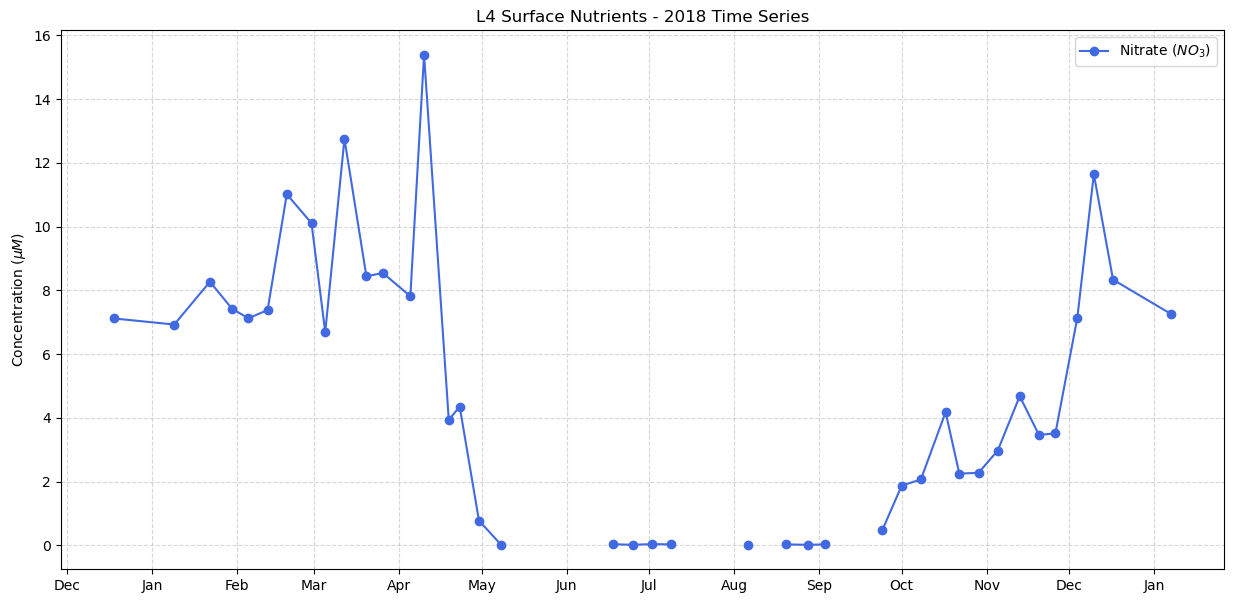

In [31]:
plt.figure(figsize=(15, 7))

# Plotting the 4 main nutrients
plt.plot(L4_2018_surface['Date'], L4_2018_surface['NITRATE'], marker = 'o', label='Nitrate ($NO_3$)', color='royalblue')


# Axis formatting
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.title('L4 Surface Nutrients - 2018 Time Series')
plt.ylabel('Concentration ($\mu M$)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

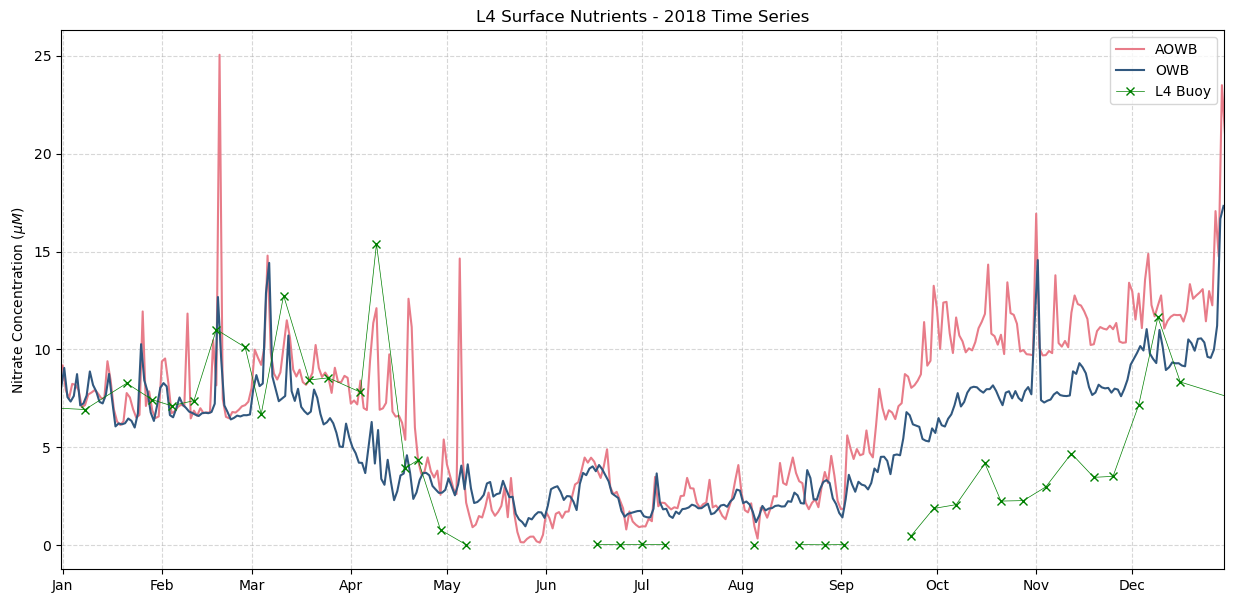

In [32]:
plt.figure(figsize=(15, 7))

plt.plot(AOWB_N3_n['2x2'].isel(deptht = 1).time_counter.values, AOWB_N3_n['2x2'].isel(deptht = 1).values, label = 'AOWB',color = c_aowb)
plt.plot(OWB_N3_n['2x2'].isel(deptht = 1).time_counter.values, OWB_N3_n['2x2'].isel(deptht = 1).values, label = 'OWB',color = c_owb)

plt.plot(L4_2018_surface['Date'], L4_2018_surface['NITRATE'], marker = 'x',linewidth = 0.5, label='L4 Buoy', color='green')


# Axis formatting
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

time_min = OWB['cell_375_725'].time_counter.min().values
time_max = OWB['cell_375_725'].time_counter.max().values
ax.set_xlim(time_min, time_max)

plt.title('L4 Surface Nutrients - 2018 Time Series')
plt.ylabel('Nitrate Concentration ($\mu M$)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

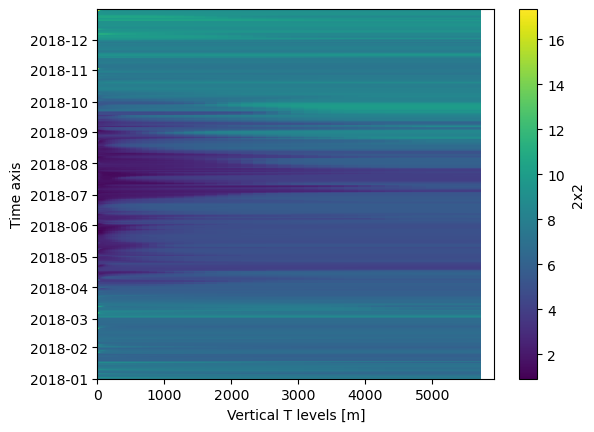

In [33]:
OWB_N3_n['2x2'].plot()

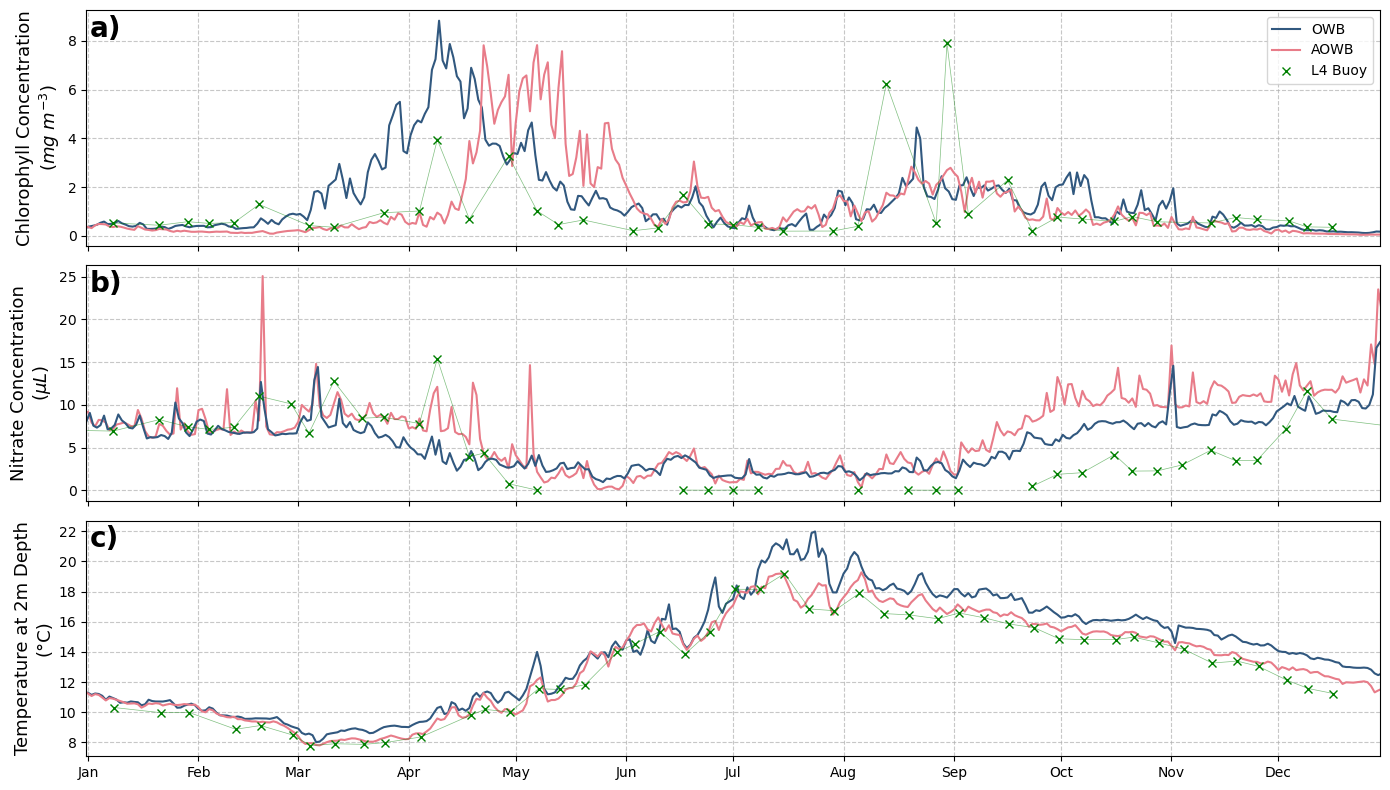

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fontsize_axis = 13

fig, (ax1, ax3, ax2) = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

ax1.plot(OWB['cell_375_725'].time_counter, OWB['cell_375_725'].values, 
         label='OWB', color=c_owb)
ax1.plot(AOWB['cell_375_725'].time_counter, AOWB['cell_375_725'].values, 
         label='AOWB', color=c_aowb)
ax1.plot(L4_chlor_surface['date'], L4_chlor_surface[' chlorophyll a (µg L-1)'], 
         linewidth=0.5, color='green', alpha=0.5)
ax1.plot(L4_chlor_surface['date'], L4_chlor_surface[' chlorophyll a (µg L-1)'], 
         'x', color='green', label='L4 Buoy')

ax1.set_ylabel('Chlorophyll Concentration\n($mg$ $m^{-3}$)',fontsize=fontsize_axis)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper right')

ax2.plot(OWB_temp['2x2'].isel(deptht=1).time_counter, OWB_temp['2x2'].isel(deptht=1).values, 
         label='OWB', color=c_owb)
ax2.plot(AOWB_temp['2x2'].isel(deptht=1).time_counter, AOWB_temp['2x2'].isel(deptht=1).values, 
         label='AOWB', color=c_aowb)
ax2.plot(L4_surface_temp.time_ref, L4_surface_temp.temp_ref, 
         linewidth=0.5, alpha=0.5, color='green')
ax2.plot(L4_surface_temp.time_ref, L4_surface_temp.temp_ref, 
         'x', label='L4 Buoy', color='green')

ax2.set_ylabel('Temperature at 2m Depth\n(°C)',fontsize=fontsize_axis)
ax2.grid(True, linestyle='--', alpha=0.7)


ax3.plot(AOWB_N3_n['2x2'].isel(deptht = 1).time_counter.values, AOWB_N3_n['2x2'].isel(deptht = 1).values, label = 'AOWB',color = c_aowb)
ax3.plot(OWB_N3_n['2x2'].isel(deptht = 1).time_counter.values, OWB_N3_n['2x2'].isel(deptht = 1).values, label = 'OWB',color = c_owb)

ax3.plot(L4_2018_surface['Date'], L4_2018_surface['NITRATE'],
         linewidth = 0.5, alpha = 0.5, color='green')
ax3.plot(L4_2018_surface['Date'], L4_2018_surface['NITRATE'],
         'x', label='L4 Buoy', color='green')

ax3.grid(True, linestyle='--', alpha=0.7)
ax3.set_ylabel('Nitrate Concentration\n($\mu L$)',fontsize=fontsize_axis)

ax3.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=2))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax3.tick_params(axis='x', labelsize=14)

time_min = OWB['cell_375_725'].time_counter.min().values
time_max = OWB['cell_375_725'].time_counter.max().values
ax2.set_xlim(time_min, time_max)


label_style = dict(fontsize=20, fontweight='bold', va='top', ha='left')
ax1.text(0.003, 0.98, 'a)', transform=ax1.transAxes, **label_style)
ax3.text(0.003, 0.98, 'b)', transform=ax3.transAxes, **label_style)
ax2.text(0.003, 0.98, 'c)', transform=ax2.transAxes, **label_style)

plt.tight_layout()
plt.savefig('L4_Chl_N3_n_Temp_Comparison_2018.png', dpi=600, bbox_inches='tight')
plt.show()